In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Read the crop recommendation dataset from CSV file
df = pd.read_csv("Crop_recommendation.csv")

In [2]:
# View the first 5 rows of the dataset
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
# Check the data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [4]:
# Get the number of rows and columns of the dataset
df.shape

(2200, 8)

In [5]:
# View statistical summary (mean, median, min, max, quartile, std dev) for numeric features
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
# Count the number of non-null values across all columns where the Nitrogen ('N') level is 0
print(df[df['N'] == 0].count())

N              27
P              27
K              27
temperature    27
humidity       27
ph             27
rainfall       27
label          27
dtype: int64


In [7]:
# List the unique crop names (labels) that can grow with zero Nitrogen ('N')
print(df[df['N'] == 0]['label'].unique())

['kidneybeans' 'pigeonpeas' 'mothbeans' 'mungbean' 'lentil' 'pomegranate'
 'mango' 'grapes' 'apple' 'orange' 'coconut']


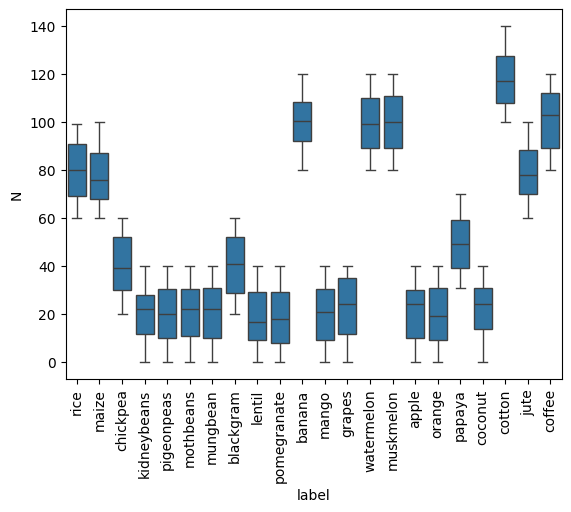

In [8]:
# Visualize the distribution of Nitrogen ('N') across different crop labels
sns.boxplot(x='label', y='N', data=df)
plt.xticks(rotation=90)
plt.show()

In [9]:
# Check for missing values in each column of the Dataset
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [10]:
# Check for logical anomalies
logical_anomalies = df[
    (df['rainfall'] < 0) |                 # Negative rainfall
    (df['temperature'] < 0) |              # Unrealistic low temperature
    (df['temperature'] > 50) |             # Unrealistic high temperature
    (df['humidity'] < 0) |                 # Humidity below 0%
    (df['humidity'] > 100) |               # Humidity above 100%
    (df['ph'] < 0) |                       # pH below 0
    (df['ph'] > 14) |                      # pH above 14
    (df['N'] < 0) |                        # Negative Nitrogen
    (df['P'] < 0) |                        # Negative Phosphorus
    (df['K'] < 0)                          # Negative Potassium
]

print("Number of logical anomalies:", len(logical_anomalies))

if logical_anomalies.empty:
    print("No logical anomalies found.")
else:
    print(logical_anomalies)

Number of logical anomalies: 0
No logical anomalies found.


In [11]:
#Count the number of data points (samples) available for each crop label
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [12]:
#Check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [13]:
# Iterate through all feature columns except target label column
for column in df.columns[:-1]:

    # Calculate first quartile (25th percentile)
    Q1 = df[column].quantile(0.25)

    # Calculate third quartile (75th percentile)
    Q3 = df[column].quantile(0.75)

    # Compute Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Define lower bound for outlier detection
    lower = Q1 - 1.5 * IQR

    # Define upper bound for outlier detection
    upper = Q3 + 1.5 * IQR

    # Identify observations outside lower and upper limits
    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(
        f"{column}: {len(outliers)} outliers"
    )

N: 0 outliers
P: 138 outliers
K: 200 outliers
temperature: 86 outliers
humidity: 30 outliers
ph: 57 outliers
rainfall: 100 outliers


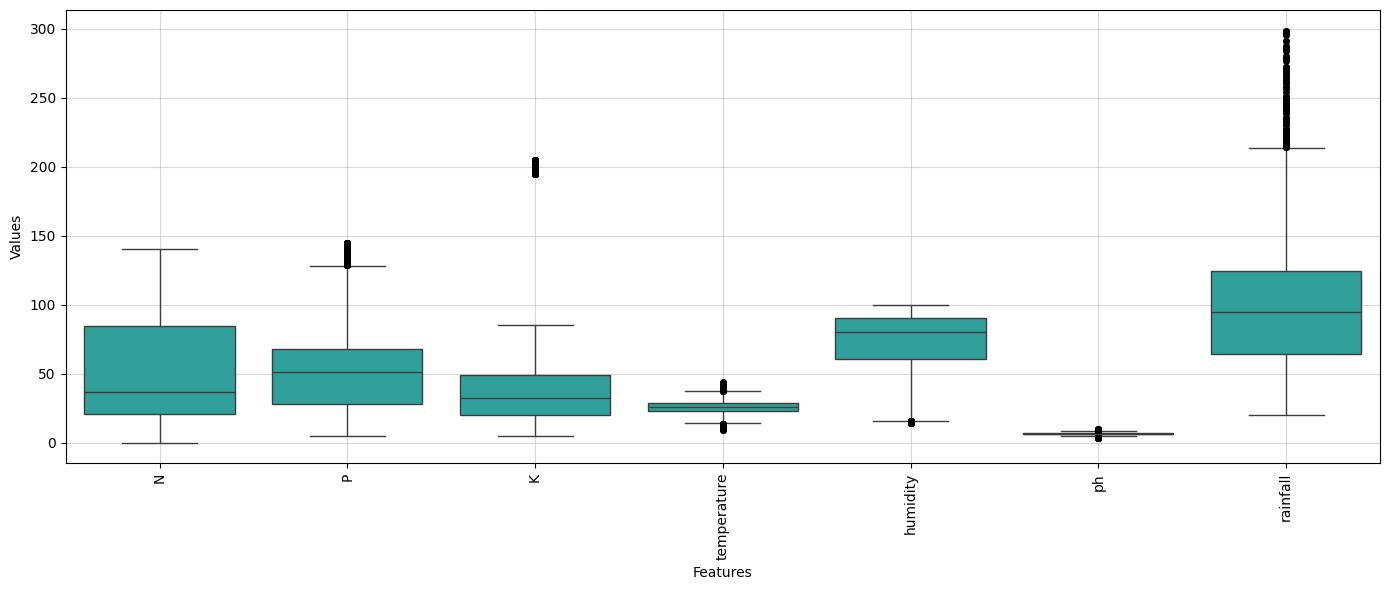

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Seaborn boxplot across all feature columns
sns.boxplot(
    data=df.iloc[:, :-1],
    color="lightseagreen",
    flierprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 4,
    },
)

# Apply title, axis labels, rotation, and grid setup
plt.xlabel("Features", fontsize=10)
plt.ylabel("Values", fontsize=10)
plt.xticks(rotation=90)
plt.grid(True, linestyle="-", alpha=0.5)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = df.drop('label', axis=1) # Independent variables (features)
y = df['label']              # Dependent variable (target crop)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize StandardScaler object
# Used to normalize feature values to zero mean and unit variance
scaler = StandardScaler()

# Learn scaling parameters from training dataset
# and transform training features
X_train_scaled = scaler.fit_transform(X_train)

# Apply previously learned scaling parameters
# to testing dataset
X_test_scaled = scaler.transform(
    X_test
)

print("Scaling completed")

Scaling completed


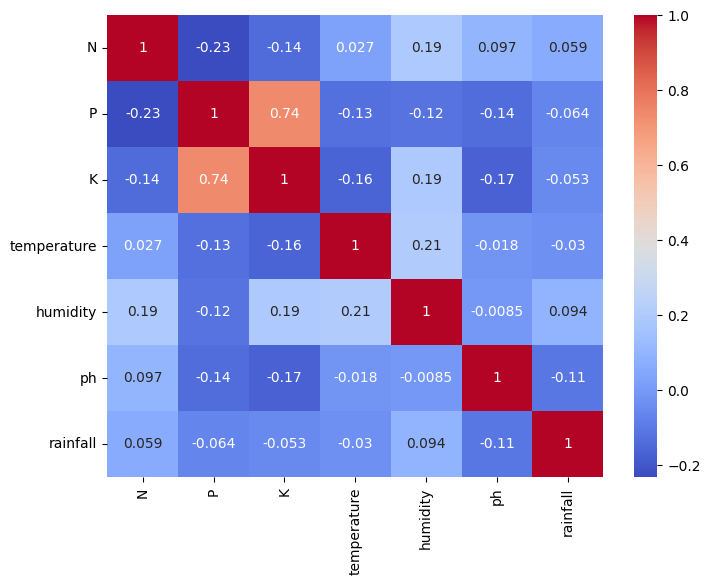

In [16]:
# Visualize correlations between numerical features using a heatmap (Feature correlation matrix)
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

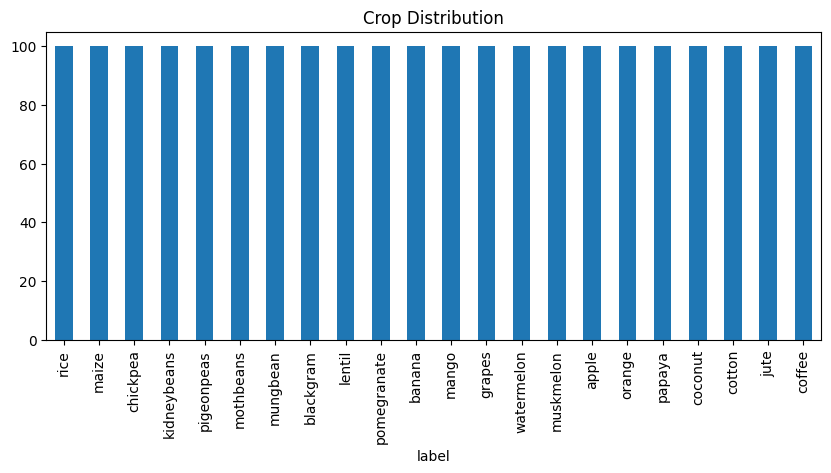

In [17]:
# Plot the frequency distribution of each crop category as a bar chart
df['label'].value_counts().plot(kind='bar', figsize=(10,4))
plt.title("Crop Distribution")
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_score

# Scale the data (Required for KNN, optional for RF)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # Can use unscaled or scaled data

# Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)  # Naive Bayes does not require feature scaling

GaussianNB()

In [19]:
# Create new soil and environmental data for prediction
# Format: [Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH, Rainfall]
new_soil_data = [[88, 40, 41, 19.8, 83.6, 5.6, 200.6]]

# Use the trained Random Forest model (rf) to predict the crop
prediction = rf.predict(new_soil_data)
print(f"The recommended crop is: {prediction[0]}")

# Scale the new soil input data using the same scaler
# Use the trained KNN model to predict the crop
new_soil_data_scaled = scaler.transform(new_soil_data)
prediction = knn.predict(new_soil_data_scaled)
print(f"The knn recommended crop is: {prediction[0]}")

# Use the trained Naive Bayes (nb) to predict the crop
prediction = nb.predict(new_soil_data)
print(f"The Naive Bayes recommended crop is: {prediction[0]}")

The recommended crop is: rice
The knn recommended crop is: rice
The Naive Bayes recommended crop is: rice


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [20]:
# Create new soil and environmental data for prediction
# Format: [Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH, Rainfall]
new_soil_data = [[100, 46, 10, 25.5, 67.2, 5.6, 74.5]]

# Use the trained Random Forest model (rf) to predict the crop
prediction = rf.predict(new_soil_data)
print(f"The rf recommended crop is: {prediction[0]}")

# Scale the new soil input data using the same scaler
# Use the trained KNN model to predict the crop
new_soil_data_scaled = scaler.transform(new_soil_data)
prediction = knn.predict(new_soil_data_scaled)
print(f"The knn recommended crop is: {prediction[0]}")

# Use the trained Naive Bayes (nb) to predict the crop
prediction = nb.predict(new_soil_data)
print(f"The Naive Bayes recommended crop is: {prediction[0]}")

The rf recommended crop is: maize
The knn recommended crop is: maize
The Naive Bayes recommended crop is: maize


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [21]:
# Create new soil and environmental data for prediction
# Format: [Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH, Rainfall]
new_soil_data = [[104, 18, 30, 23.60302, 60.39647, 6.779833, 140.937]]

# Use the trained Random Forest model (rf) to predict the crop
prediction = rf.predict(new_soil_data)
print(f"The rf recommended crop is: {prediction[0]}")

# Scale the new soil input data using the same scaler
# Use the trained KNN model to predict the crop
new_soil_data_scaled = scaler.transform(new_soil_data)
prediction = knn.predict(new_soil_data_scaled)
print(f"The knn recommended crop is: {prediction[0]}")

# Use the trained Naive Bayes (nb) to predict the crop
prediction = nb.predict(new_soil_data)
print(f"The Naive Bayes recommended crop is: {prediction[0]}")

The rf recommended crop is: coffee
The knn recommended crop is: coffee
The Naive Bayes recommended crop is: coffee


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [22]:
# Make predictions on the test dataset using the trained KNN model
knn_pred = knn.predict(X_test_scaled)

# Make predictions on the test dataset using the trained Random Forest model
rf_pred = rf.predict(X_test)

# Make predictions on the test dataset using the trained Naive Bayes model
nb_pred = nb.predict(X_test)

# Print the accuracy scores of both models
print(f"KNN Accuracy: {accuracy_score(y_test, knn_pred):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_pred):.4f}")

KNN Accuracy: 0.9568
Random Forest Accuracy: 0.9932
Naive Bayes Accuracy: 0.9955


In [23]:
# Compare training accuracy vs test accuracy
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

train_acc_knn = knn.score(X_train_scaled, y_train)
test_acc_knn = knn.score(X_test_scaled, y_test)

train_acc_nb = nb.score(X_train, y_train)
test_acc_nb = nb.score(X_test, y_test)

print(f"RF Training Accuracy: {train_acc * 100:.2f}%")
print(f"RF Test Accuracy: {test_acc * 100:.2f}%")

print(f"KNN Training Accuracy: {train_acc_knn * 100:.2f}%")
print(f"KNN Test Accuracy: {test_acc_knn * 100:.2f}%")

print(f"Naive Bayes Training Accuracy: {train_acc_nb * 100:.2f}%")
print(f"Naive Bayes Test Accuracy: {test_acc_nb * 100:.2f}%")

RF Training Accuracy: 100.00%
RF Test Accuracy: 99.32%
KNN Training Accuracy: 98.69%
KNN Test Accuracy: 95.68%
Naive Bayes Training Accuracy: 99.49%
Naive Bayes Test Accuracy: 99.55%


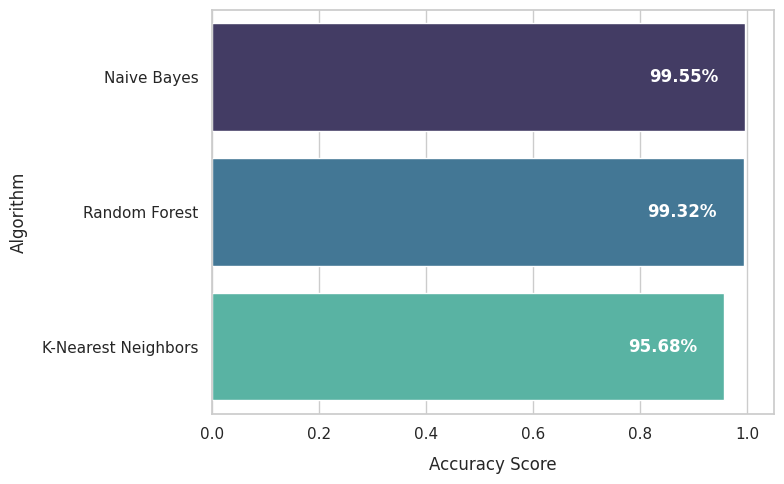

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


# Calculate accuracy scores for all three models

# 1. Calculate accuracy scores
rf_acc = accuracy_score(y_test, rf.predict(X_test))
knn_acc = accuracy_score(y_test, knn.predict(X_test_scaled))
nb_acc = accuracy_score(y_test, nb.predict(X_test))


# 2. Create a dictionary to store model names and accuracies
data = {
    'Model': [
        'Random Forest',
        'K-Nearest Neighbors',
        'Naive Bayes'
    ],
    'Accuracy': [
        rf_acc,
        knn_acc,
        nb_acc
    ]
}

df_accuracy = pd.DataFrame(data).sort_values(
    by='Accuracy',
    ascending=False
)


# 3. Plotting the comparison chart
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))


# 4. Create horizontal bar plot
barplot = sns.barplot(
    x='Accuracy',
    y='Model',
    hue='Model',
    data=df_accuracy,
    palette='mako',
    ax=ax,
    legend=False
)


# 5. Add exact percentage text inside/next to the bars
for index, row in df_accuracy.reset_index(drop=True).iterrows():
    ax.text(
        row['Accuracy'] - 0.05 if row['Accuracy'] > 0.1 else row['Accuracy'] + 0.01,
        index,
        f"{row['Accuracy'] * 100:.2f}%",
        color='white' if row['Accuracy'] > 0.1 else 'black',
        va='center',
        ha='right' if row['Accuracy'] > 0.1 else 'left',
        fontweight='bold'
    )


# 6. Clean up layout, labels, and boundaries

ax.set_xlabel('Accuracy Score', fontsize=12, labelpad=10)
ax.set_ylabel('Algorithm', fontsize=12, labelpad=10)
ax.set_xlim(0, 1.05)


plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

# ---------------- KNN ----------------

knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

knn_precision, knn_recall, knn_f1, _ = precision_recall_fscore_support(
    y_test,
    knn_pred,
    average="weighted"
)

# ---------------- Random Forest ----------------

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_precision, rf_recall, rf_f1, _ = precision_recall_fscore_support(
    y_test,
    rf_pred,
    average="weighted"
)

# ---------------- NB ----------------

nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

nb_precision, nb_recall, nb_f1, _ = precision_recall_fscore_support(
    y_test,
    nb_pred,
    average="weighted"
)

# ---------------- Results ----------------

results = pd.DataFrame({
    "Model": ["K-Nearest Neighbors", "Random Forest", "Naive Bayes"],
    "Precision (%)": [knn_precision * 100, rf_precision * 100, nb_precision * 100],
    "Recall (%)": [knn_recall * 100, rf_recall * 100, nb_recall * 100],
    "F1-Score (%)": [knn_f1 * 100, rf_f1 * 100, rf_f1 * 100]
})

print(results.round(2))

                 Model  Precision (%)  Recall (%)  F1-Score (%)
0  K-Nearest Neighbors          96.29       95.68         95.67
1        Random Forest          99.37       99.32         99.32
2          Naive Bayes          99.58       99.55         99.32


In [26]:
# Display classification metrics for Random Forest predictions
print("--- Random Forest Report ---")
print(classification_report(y_test, rf_pred))

# Display classification metrics for KNN predictions
print("\n--- KNN Report ---")
print(classification_report(y_test, knn_pred))

# Display classification metrics for NB predictions
print("\n--- Naive Bayes Report ---")
print(classification_report(y_test, nb_pred))

--- Random Forest Report ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        1

Text(0.5, 1.0, 'K-Nearest Neighbor Confusion Matrix')

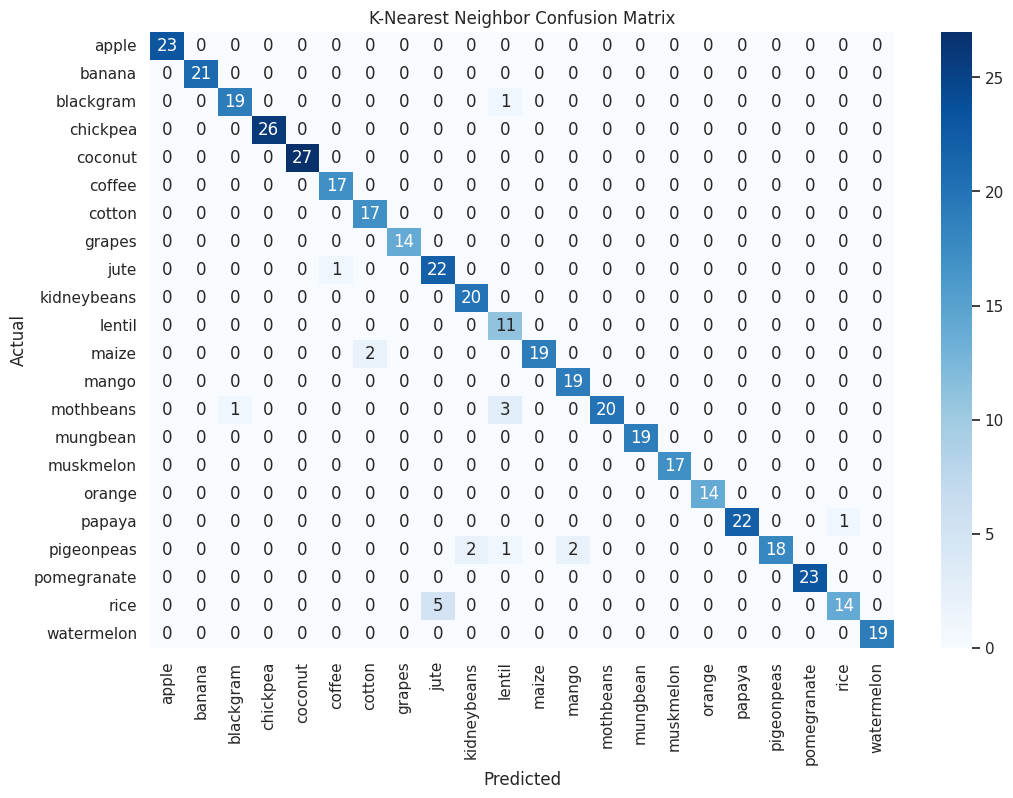

In [27]:
# K-Nearest Neighbor
# Create a figure for plotting with size 12x8 inches
# Create a heatmap visualization of the confusion matrix
plt.figure(figsize=(12,8))
cm = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('K-Nearest Neighbor Confusion Matrix')

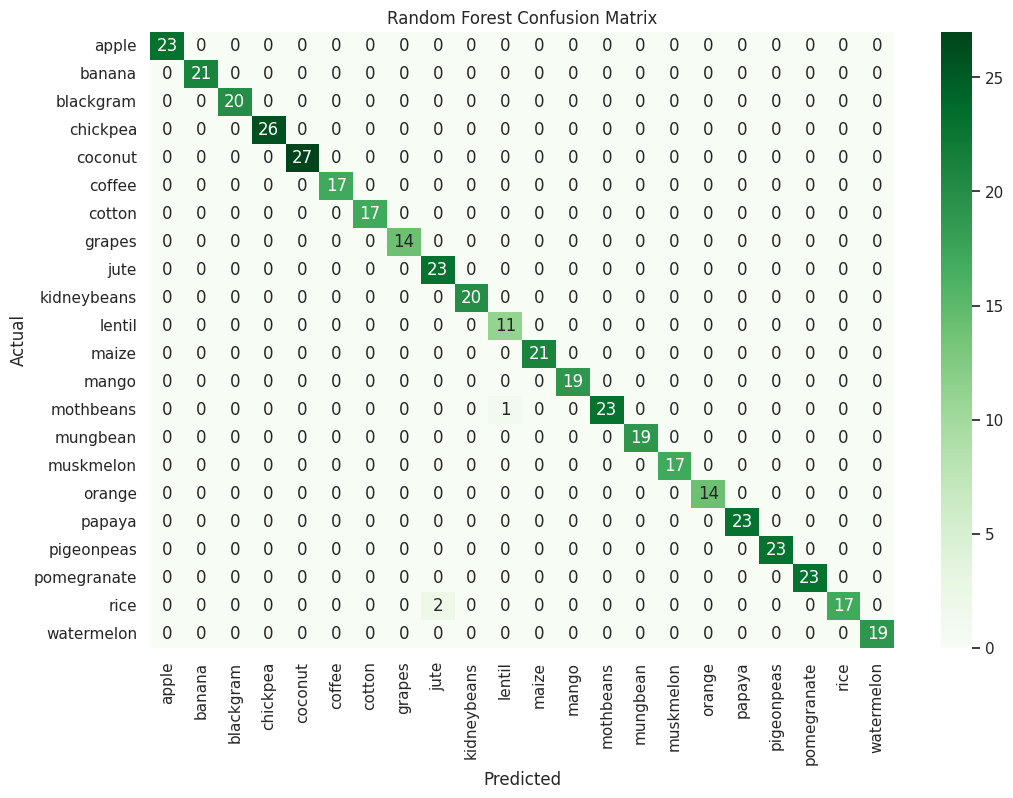

In [28]:
# Random Forest
# Create a figure for plotting with size 12x8 inches
# Create a heatmap visualization of the confusion matrix
plt.figure(figsize=(12,8))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

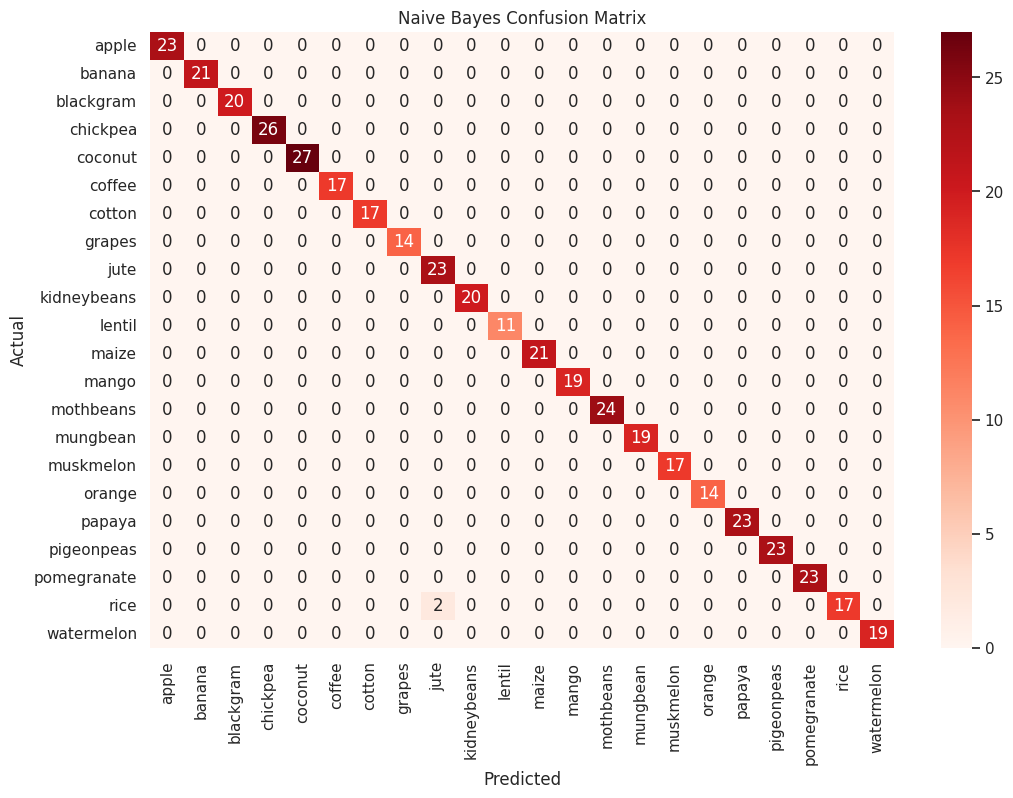

In [29]:
# Naive Bayes
# Create a figure for plotting with size 12x8 inches
# Create a heatmap visualization of the confusion matrix
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, nb_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=nb.classes_,
    yticklabels=nb.classes_,
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [30]:
# Check Random Forest stability

# Perform 5-fold cross-validation for the KNN model
knn_cv_scores = cross_val_score(knn, X, y, cv=5)

# Print the average and standard deviation cross-validation accuracy of KNN
print(f"KNN Cross-Val Mean: {knn_cv_scores.mean():.4f}")
print(f"KNN Standard Deviation: {knn_cv_scores.std():.4f}")

# Perform 5-fold cross-validation for Random Forest model
rf_cv_scores = cross_val_score(rf, X, y, cv=5)

# Print the average and standard deviation cross-validation accuracy of Random Forest
print(f"RF Cross-Val Mean: {rf_cv_scores.mean():.4f}")
print(f"RF Standard Deviation: {rf_cv_scores.std():.4f}")

# Perform 5-fold cross-validation for Naive Bayes model
nb_cv_scores = cross_val_score(nb, X, y, cv=5)

# Print the average and standard deviation cross-validation accuracy of Naive Bayes
print(f"NB Cross-Val Mean: {nb_cv_scores.mean():.4f}")
print(f"NB Standard Deviation: {nb_cv_scores.std():.4f}")

KNN Cross-Val Mean: 0.9795
KNN Standard Deviation: 0.0014
RF Cross-Val Mean: 0.9945
RF Standard Deviation: 0.0034
NB Cross-Val Mean: 0.9950
NB Standard Deviation: 0.0022


In [31]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define results dictionary
grid_results = {}

# ==========================================
# 1. KNN GRID SEARCH (Scaling Required)
# ==========================================
knn_pipeline = Pipeline(
    [('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]
)

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan'],
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

knn_grid.fit(X_train, y_train)
grid_results['KNN'] = {
    'best_params': knn_grid.best_params_,
    'best_score': knn_grid.best_score_,
    'test_score': knn_grid.score(X_test, y_test),
}

# ==========================================
# 2. RANDOM FOREST GRID SEARCH
# ==========================================
rf_pipeline = Pipeline([('rf', RandomForestClassifier(random_state=42))])

rf_param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__criterion': ['gini', 'entropy'],
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

rf_grid.fit(X_train, y_train)
grid_results['Random Forest'] = {
    'best_params': rf_grid.best_params_,
    'best_score': rf_grid.best_score_,
    'test_score': rf_grid.score(X_test, y_test),
}

# ==========================================
# 3. NAIVE BAYES GRID SEARCH (Scaling + Smoothing)
# ==========================================
nb_pipeline = Pipeline(
    [('scaler', StandardScaler()), ('nb', GaussianNB())]
)

nb_param_grid = {'nb__var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]}

nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

nb_grid.fit(X_train, y_train)
grid_results['Naive Bayes'] = {
    'best_params': nb_grid.best_params_,
    'best_score': nb_grid.best_score_,
    'test_score': nb_grid.score(X_test, y_test),
}

# ==========================================
# PRINT GRID SEARCH SUMMARY
# ==========================================
for model_name, metrics in grid_results.items():
  print(f'=== {model_name} ===')
  print(f'Best Parameters: {metrics["best_params"]}')
  print(f'Best CV Accuracy: {metrics["best_score"]*100:.2f}%')
  print(f'Test Accuracy:    {metrics["test_score"]*100:.2f}%\n')

=== KNN ===
Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best CV Accuracy: 98.30%
Test Accuracy:    97.50%

=== Random Forest ===
Best Parameters: {'rf__criterion': 'gini', 'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best CV Accuracy: 99.49%
Test Accuracy:    99.32%

=== Naive Bayes ===
Best Parameters: {'nb__var_smoothing': 1e-11}
Best CV Accuracy: 99.55%
Test Accuracy:    99.55%



In [32]:
import pandas as pd
from scipy.stats import loguniform, randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define results dictionary
random_search_results = {}

# ==========================================
# 1. KNN RANDOM SEARCH (Scaling Required)
# ==========================================
knn_pipeline = Pipeline(
    [('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]
)

knn_param_dist = {
    'knn__n_neighbors': randint(1, 30),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
    'knn__p': [1, 2],  # 1 = manhattan, 2 = euclidean
}

knn_random = RandomizedSearchCV(
    estimator=knn_pipeline,
    param_distributions=knn_param_dist,
    n_iter=15,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
)

knn_random.fit(X_train, y_train)
random_search_results['KNN'] = {
    'best_params': knn_random.best_params_,
    'best_score': knn_random.best_score_,
    'test_score': knn_random.score(X_test, y_test),
}

# ==========================================
# 2. RANDOM FOREST RANDOM SEARCH
# ==========================================
rf_pipeline = Pipeline([('rf', RandomForestClassifier(random_state=42))])

rf_param_dist = {
    'rf__n_estimators': randint(50, 300),
    'rf__max_depth': [None] + list(range(5, 30, 5)),
    'rf__min_samples_split': randint(2, 11),
    'rf__min_samples_leaf': randint(1, 10),
    'rf__criterion': ['gini', 'entropy'],
}

rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
)

rf_random.fit(X_train, y_train)
random_search_results['Random Forest'] = {
    'best_params': rf_random.best_params_,
    'best_score': rf_random.best_score_,
    'test_score': rf_random.score(X_test, y_test),
}

# ==========================================
# 3. NAIVE BAYES RANDOM SEARCH (Log-Uniform Distribution)
# ==========================================
nb_pipeline = Pipeline(
    [('scaler', StandardScaler()), ('nb', GaussianNB())]
)

# loguniform samples continuously across exponential scales (1e-11 to 1e-3)
nb_param_dist = {'nb__var_smoothing': loguniform(1e-11, 1e-3)}

nb_random = RandomizedSearchCV(
    estimator=nb_pipeline,
    param_distributions=nb_param_dist,
    n_iter=15,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
)

nb_random.fit(X_train, y_train)
random_search_results['Naive Bayes'] = {
    'best_params': nb_random.best_params_,
    'best_score': nb_random.best_score_,
    'test_score': nb_random.score(X_test, y_test),
}

# ==========================================
# PRINT RANDOM SEARCH SUMMARY
# ==========================================
for model_name, metrics in random_search_results.items():
  print(f'=== {model_name} ===')
  print(f'Best Parameters: {metrics["best_params"]}')
  print(f'Best CV Accuracy: {metrics["best_score"]*100:.2f}%')
  print(f'Test Accuracy:    {metrics["test_score"]*100:.2f}%\n')

=== KNN ===
Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 6, 'knn__p': 2, 'knn__weights': 'distance'}
Best CV Accuracy: 98.41%
Test Accuracy:    97.27%

=== Random Forest ===
Best Parameters: {'rf__criterion': 'gini', 'rf__max_depth': None, 'rf__min_samples_leaf': 3, 'rf__min_samples_split': 8, 'rf__n_estimators': 293}
Best CV Accuracy: 99.38%
Test Accuracy:    99.32%

=== Naive Bayes ===
Best Parameters: {'nb__var_smoothing': np.float64(9.915644566638387e-09)}
Best CV Accuracy: 99.55%
Test Accuracy:    99.55%



=== MODEL PERFORMANCE COMPARISON (Test Accuracy %) ===
Stage          Baseline (Default)  Grid Search  Random Search
Model                                                        
KNN                         95.68        97.50          97.27
Naive Bayes                 99.55        99.55          99.55
Random Forest               99.32        99.32          99.32


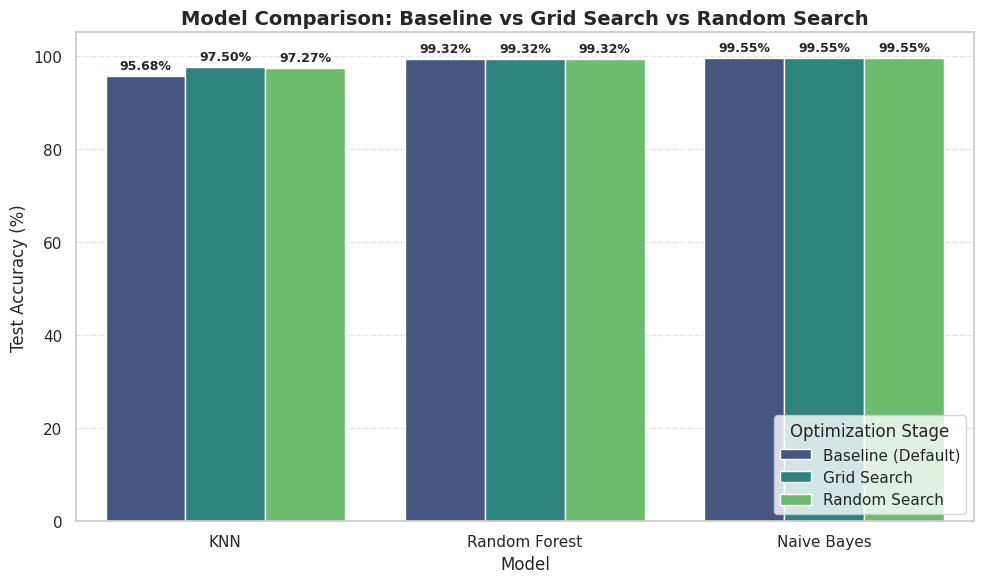

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# 1. TRAIN BASELINE MODELS (Before Tuning)
# ==========================================
baseline_knn = Pipeline(
    [('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]
).fit(X_train, y_train)
baseline_rf = Pipeline(
    [('rf', RandomForestClassifier(random_state=42))]
).fit(X_train, y_train)
baseline_nb = Pipeline(
    [('scaler', StandardScaler()), ('nb', GaussianNB())]
).fit(X_train, y_train)

# ==========================================
# 2. AGGREGATE RESULTS INTO DATAFRAME
# ==========================================
comparison_data = [
    # Baseline
    {
        'Model': 'KNN',
        'Stage': 'Baseline (Default)',
        'Accuracy': baseline_knn.score(X_test, y_test),
    },
    {
        'Model': 'Random Forest',
        'Stage': 'Baseline (Default)',
        'Accuracy': baseline_rf.score(X_test, y_test),
    },
    {
        'Model': 'Naive Bayes',
        'Stage': 'Baseline (Default)',
        'Accuracy': baseline_nb.score(X_test, y_test),
    },
    # Grid Search
    {
        'Model': 'KNN',
        'Stage': 'Grid Search',
        'Accuracy': knn_grid.score(X_test, y_test),
    },
    {
        'Model': 'Random Forest',
        'Stage': 'Grid Search',
        'Accuracy': rf_grid.score(X_test, y_test),
    },
    {
        'Model': 'Naive Bayes',
        'Stage': 'Grid Search',
        'Accuracy': nb_grid.score(X_test, y_test),
    },
    # Random Search
    {
        'Model': 'KNN',
        'Stage': 'Random Search',
        'Accuracy': knn_random.score(X_test, y_test),
    },
    {
        'Model': 'Random Forest',
        'Stage': 'Random Search',
        'Accuracy': rf_random.score(X_test, y_test),
    },
    {
        'Model': 'Naive Bayes',
        'Stage': 'Random Search',
        'Accuracy': nb_random.score(X_test, y_test),
    },
]

df_comparison = pd.DataFrame(comparison_data)

# Convert accuracy to percentage for display
df_comparison['Accuracy (%)'] = df_comparison['Accuracy'] * 100

# ==========================================
# 3. DISPLAY COMPARISON TABLE
# ==========================================
pivot_df = df_comparison.pivot(
    index='Model', columns='Stage', values='Accuracy (%)'
)
print("=== MODEL PERFORMANCE COMPARISON (Test Accuracy %) ===")
print(
    pivot_df[['Baseline (Default)', 'Grid Search', 'Random Search']].round(2)
)

# ==========================================
# 4. PLOT COMPARATIVE BAR CHART
# ==========================================
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_comparison,
    x='Model',
    y='Accuracy (%)',
    hue='Stage',
    palette='viridis',
)

# Add values above bars
for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f'{height:.2f}%',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
    )

plt.title(
    'Model Comparison: Baseline vs Grid Search vs Random Search',
    fontsize=14,
    fontweight='bold',
)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 105)
plt.legend(title='Optimization Stage', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
import joblib

# Save the model to a file
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(knn, 'knn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(nb, 'navies_bayes_model.pkl')

print("Model saved successfully!")

Model saved successfully!


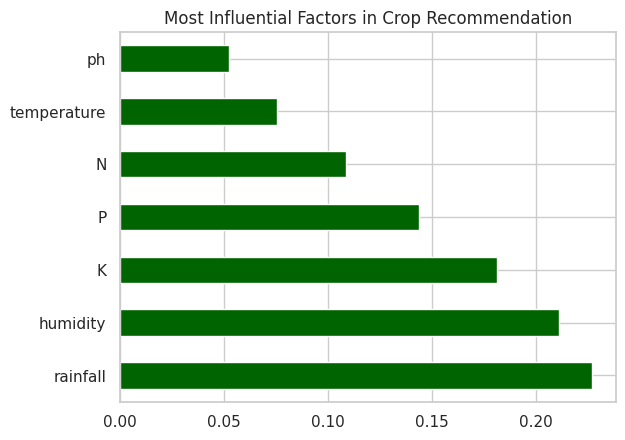

In [35]:
import matplotlib.pyplot as plt

# Most influential factors  in importance of each feature
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(7).plot(kind='barh', color='darkgreen')
plt.title('Most Influential Factors in Crop Recommendation')
plt.show()